### **Transformers multimodales y modelos fundacionales**


Este cuaderno presenta una lectura técnica y experimental de la evolución:

**BERT -> VisualBERT -> ViLBERT -> LXMERT -> UNITER -> ViLT -> FLAVA / SimVLM / CoCa -> BLIP-2 -> LLaVA -> Qwen2.5-VL / InternVL**

El cuaderno está diseñado para ejecutarse en el entorno reproducible del curso MCC225, idealmente desde Docker/JupyterLab. La parte experimental incluye implementaciones ligeras y demostraciones autocontenidas para evitar depender de descargas pesadas. Cuando sea viable, se dejan celdas opcionales para usar modelos de Hugging Face o bibliotecas instaladas en el entorno.


### **Entorno reproducible del curso**

#### **Uso esperado con Docker**

El curso MCC225 usa un flujo reproducible con imágenes separadas para CPU y GPU:

- `mcc225_cpu`: recomendado para Windows con Docker Desktop y también para Linux sin GPU.
- `mcc225_gpu`: recomendado para Linux con GPU NVIDIA y NVIDIA Container Toolkit.
- JupyterLab se expone en el puerto `8899`.
- El cuaderno debe poder correr en CPU en modo demostrativo.
- Las celdas de modelos pesados deben tratarse como opcionales.

Comandos mínimos sugeridos dentro del repositorio:

```bash
docker build --no-cache --build-arg TORCH_FLAVOR=cpu --build-arg INSTALL_OPCIONAL=true -t mcc225_cpu .
docker run -it --rm --name mcc225_cpu_container -p 8899:8899 -v "$(pwd)":/workspace mcc225_cpu
```

Para Linux con GPU:

```bash
docker context use default
docker build --no-cache --build-arg TORCH_FLAVOR=cu121 --build-arg INSTALL_OPCIONAL=true -t mcc225_gpu .
docker run -it --rm --gpus all --name mcc225_gpu_container -p 8899:8899 -v "$(pwd)":/workspace mcc225_gpu
```

Al iniciar el contenedor, abrir:

```text
http://localhost:8899/lab
```

In [1]:
# Configuración inicial del cuaderno.
# Todos los comentarios y cadenas de texto están en español para mantener coherencia con el curso.

import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

SEED = 22509
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Entorno MCC225")
print("PyTorch:", torch.__version__)
print("Dispositivo activo:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Sin GPU visible: el cuaderno funcionará en modo CPU/demostrativo.")

Entorno MCC225
PyTorch: 2.4.1+cu124
Dispositivo activo: cuda
GPU: NVIDIA GeForce RTX 4080 SUPER


#### **Objetivos de aprendizaje**

Al terminar este cuaderno, el estudiante debe poder:

1. Diferenciar arquitecturas **dual encoder**, **single-stream**, **two-stream**, **cross-modal encoder**, **encoder-decoder multimodal** y **MLLM con LLM congelado**.
2. Relacionar cada arquitectura con papers concretos.
3. Identificar objetivos de preentrenamiento: **MLM**, **MRM**, **ITM**, **WRA**, **contrastive loss**, **captioning loss** e **instruction tuning**.
4. Comparar modelos de comprensión multimodal frente a modelos generativos multimodales.
5. Justificar cuándo usar **CLIP**, **ViLT**, **BLIP**, **BLIP-2**, **LLaVA** o **Qwen2.5-VL**.
6. Ejecutar una línea base de recuperación imagen-texto, medir **Recall@K**, analizar rankings y clasificar errores.
7. Explicar por qué los modelos modernos no son solo "modelos grandes", sino combinaciones de arquitectura, datos, objetivos, conectores y estrategias de evaluación.

### **Mapa histórico mínimo**

#### **Tabla obligatoria de familias**

| Familia | Papers | Idea central |
|---|---|---|
| Base textual | BERT | Transformer encoder para lenguaje |
| Single-stream | VisualBERT, UNITER, ViLT | Texto e imagen procesados juntos |
| Two-stream | ViLBERT | Flujos separados con co-attention |
| Cross-modal encoder | LXMERT | Encoder visual, textual y cross-modal |
| Generativos VLP | SimVLM, CoCa, BLIP | Comprensión + generación |
| Frozen components | Frozen, BLIP-2 | Imagen y LLM congelados con puente aprendible |
| Visual instruction tuning | LLaVA, LLaVA-1.5 | Asistentes multimodales entrenados con instrucciones |
| MLLMs modernos | Qwen2.5-VL, InternVL, Molmo | Documentos, grounding, video, razonamiento y agentes visuales |

#### Comentario de lectura

La evolución no es lineal en el sentido estricto. Varias familias conviven. Un sistema industrial puede usar CLIP para retrieval, BLIP-2 o LLaVA para generación, un detector para grounding y una capa de evaluación separada. La pregunta de ingeniería no es "cuál modelo es el mejor", sino **qué arquitectura minimiza costo y riesgo para una tarea concreta**.

In [2]:
# Representamos el mapa histórico como un DataFrame para poder reutilizarlo en actividades y reportes.

mapa_historico = pd.DataFrame([
    {
        "Familia": "Base textual",
        "Papers": "BERT",
        "Idea central": "Transformer encoder para lenguaje",
        "Riesgo típico": "Confundir base textual con arquitectura multimodal"
    },
    {
        "Familia": "Single-stream",
        "Papers": "VisualBERT, UNITER, ViLT",
        "Idea central": "Texto e imagen procesados juntos",
        "Riesgo típico": "Alto costo o dependencia de representación visual"
    },
    {
        "Familia": "Two-stream",
        "Papers": "ViLBERT",
        "Idea central": "Flujos visual y textual separados con co-attention",
        "Riesgo típico": "Más complejidad de entrenamiento e implementación"
    },
    {
        "Familia": "Cross-modal encoder",
        "Papers": "LXMERT",
        "Idea central": "Encoder visual, encoder textual y encoder cross-modal",
        "Riesgo típico": "Dependencia de objetos/regiones y tareas de razonamiento acotadas"
    },
    {
        "Familia": "Generativos VLP",
        "Papers": "SimVLM, CoCa, BLIP",
        "Idea central": "Comprensión y generación multimodal",
        "Riesgo típico": "Generación fluida pero no siempre grounded"
    },
    {
        "Familia": "Frozen components",
        "Papers": "Frozen, BLIP-2",
        "Idea central": "Imagen y LLM congelados con puente aprendible",
        "Riesgo típico": "El puente puede ocultar errores de alineamiento"
    },
    {
        "Familia": "Visual instruction tuning",
        "Papers": "LLaVA, LLaVA-1.5",
        "Idea central": "Asistentes multimodales entrenados con instrucciones",
        "Riesgo típico": "Alucinación visual y sobreconfianza conversacional"
    },
    {
        "Familia": "MLLMs modernos",
        "Papers": "Qwen2.5-VL, InternVL, Molmo",
        "Idea central": "Documentos, grounding, video, razonamiento y agentes visuales",
        "Riesgo típico": "Costo, reproducibilidad, evaluación incompleta y dependencia de datos"
    }
])

mapa_historico

,Familia,Papers,Idea central,Riesgo típico
0,Base textual,BERT,Transformer encoder para lenguaje,Confundir base textual con arquitectura multim...
1,Single-stream,"VisualBERT, UNITER, ViLT",Texto e imagen procesados juntos,Alto costo o dependencia de representación visual
2,Two-stream,ViLBERT,Flujos visual y textual separados con co-atten...,Más complejidad de entrenamiento e implementación
3,Cross-modal encoder,LXMERT,"Encoder visual, encoder textual y encoder cros...",Dependencia de objetos/regiones y tareas de ra...
4,Generativos VLP,"SimVLM, CoCa, BLIP",Comprensión y generación multimodal,Generación fluida pero no siempre grounded
5,Frozen components,"Frozen, BLIP-2",Imagen y LLM congelados con puente aprendible,El puente puede ocultar errores de alineamiento
6,Visual instruction tuning,"LLaVA, LLaVA-1.5",Asistentes multimodales entrenados con instruc...,Alucinación visual y sobreconfianza conversaci...
7,MLLMs modernos,"Qwen2.5-VL, InternVL, Molmo","Documentos, grounding, video, razonamiento y a...","Costo, reproducibilidad, evaluación incompleta..."


### **Del Transformer textual al Transformer multimodal**

#### **BERT como punto de partida**

BERT no es un modelo multimodal. Su valor para esta semana es conceptual: permite explicar cómo un **Transformer encoder** aprende representaciones contextuales bidireccionales mediante **masked language modeling**. VisualBERT, UNITER y ViLT heredan la idea de procesar secuencias dentro de una pila de Transformer, pero reemplazan la secuencia puramente textual por una secuencia mixta: tokens de texto más tokens visuales.

La transición conceptual es:

```text
BERT:
[CLS] texto texto [MASK] texto [SEP]

Transformer multimodal single-stream:
[CLS] texto texto [SEP] región_1 región_2 ... región_n [SEP]

Transformer multimodal con patches:
[CLS] texto texto [SEP] patch_1 patch_2 ... patch_n [SEP]
```

#### **Comentario crítico del modelo**

La ventaja de BERT es su simplicidad arquitectónica. La limitación es que el lenguaje ya viene tokenizado, mientras que una imagen requiere decidir si se representa como regiones, patches, píxeles, objetos o embeddings precomputados. Esa decisión cambia completamente el costo y el tipo de error del sistema.

In [3]:
# Demostración mínima de Masked Language Modeling (MLM).
# No se descarga BERT. Se simula el objetivo para entender qué aprende un encoder textual.

vocabulario = {
    "[PAD]": 0, "[CLS]": 1, "[SEP]": 2, "[MASK]": 3,
    "el": 4, "modelo": 5, "aprende": 6, "tokens": 7, "visuales": 8,
    "y": 9, "textuales": 10
}

tokens = ["[CLS]", "el", "modelo", "aprende", "[MASK]", "visuales", "y", "textuales", "[SEP]"]
ids = torch.tensor([[vocabulario[t] for t in tokens]], device=device)

print("Secuencia de entrada:", tokens)
print("IDs:", ids.tolist())

# En un BERT real, el modelo debería predecir el token en la posición [MASK].
posicion_mask = tokens.index("[MASK]")
objetivo_esperado = "tokens"

print("Posición enmascarada:", posicion_mask)
print("Token esperado:", objetivo_esperado)

Secuencia de entrada: ['[CLS]', 'el', 'modelo', 'aprende', '[MASK]', 'visuales', 'y', 'textuales', '[SEP]']
IDs: [[1, 4, 5, 6, 3, 8, 9, 10, 2]]
Posición enmascarada: 4
Token esperado: tokens


Forma de entrada: (1, 9, 8)
Forma de salida: (1, 9, 8)
Forma de pesos de atención: (1, 9, 9)


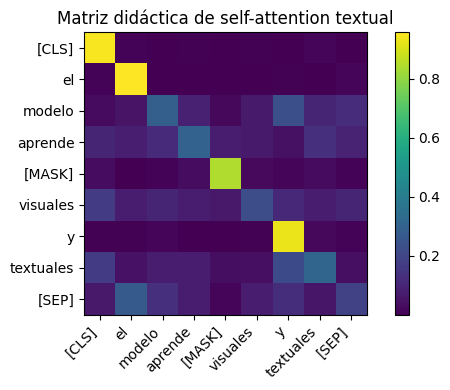

In [4]:
# Implementación didáctica de self-attention.
# Esta celda muestra cómo cada token puede consultar a todos los demás tokens de la secuencia.

def self_attention_simple(x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    x: tensor [batch, longitud, dimension]
    devuelve:
      salida: representaciones contextualizadas
      pesos: matriz de atención
    """
    d = x.shape[-1]
    Q = x
    K = x
    V = x
    logits = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d)
    pesos = torch.softmax(logits, dim=-1)
    salida = torch.matmul(pesos, V)
    return salida, pesos

batch = 1
longitud = len(tokens)
dimension = 8

embeddings_textuales = torch.randn(batch, longitud, dimension, device=device)
salida, pesos = self_attention_simple(embeddings_textuales)

print("Forma de entrada:", tuple(embeddings_textuales.shape))
print("Forma de salida:", tuple(salida.shape))
print("Forma de pesos de atención:", tuple(pesos.shape))

plt.figure(figsize=(6, 4))
plt.imshow(pesos[0].detach().cpu().numpy())
plt.xticks(range(longitud), tokens, rotation=45, ha="right")
plt.yticks(range(longitud), tokens)
plt.title("Matriz didáctica de self-attention textual")
plt.colorbar()
plt.tight_layout()
plt.show()

### **Representación visual: regiones, patches y tokens**

#### **Regiones visuales**

VisualBERT, ViLBERT, LXMERT y UNITER se apoyan históricamente en **regiones visuales** detectadas por un detector externo. Cada región puede representarse como un vector de características más información espacial, por ejemplo coordenadas de caja.

- Ventaja: las regiones tienden a capturar objetos semánticos.  
- Limitación: el sistema depende de un detector, de sus clases, de su sesgo y de su costo.

#### **Patches**

ViT y ViLT impulsan la idea de convertir una imagen en una secuencia de patches. Esto elimina parte de la dependencia de detectores de objetos y hace que el procesamiento sea más parecido al de los tokens textuales.

- Ventaja: representación más uniforme y compatible con Transformers.  
- Limitación: puede requerir más datos o perder sesgos útiles de detectores preentrenados.

#### **Embeddings visuales proyectados hacia un LLM**

BLIP-2 y LLaVA usan una estrategia distinta: extraen embeddings visuales con un encoder visual y los conectan con un LLM mediante un puente aprendible, como Q-Former o proyector MLP.

- Ventaja: reutiliza LLMs potentes sin entrenar todo desde cero.  
- Limitación: el alineamiento entre visión y lenguaje puede fallar de forma silenciosa.

Imagen: (3, 64, 64)
Patches: (16, 768)


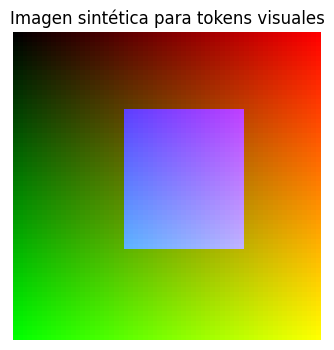

In [5]:
# Patchificación didáctica de una imagen sintética.
# La imagen se genera localmente para que el cuaderno sea reproducible sin internet.

def crear_imagen_sintetica(alto: int = 64, ancho: int = 64) -> torch.Tensor:
    """
    Crea una imagen RGB sintética con patrones simples.
    Salida: tensor [3, alto, ancho] con valores en [0, 1].
    """
    y = torch.linspace(0, 1, alto).view(1, alto, 1).expand(1, alto, ancho)
    x = torch.linspace(0, 1, ancho).view(1, 1, ancho).expand(1, alto, ancho)
    canal_rojo = x
    canal_verde = y
    canal_azul = ((x > 0.35) & (x < 0.75) & (y > 0.25) & (y < 0.70)).float()
    return torch.cat([canal_rojo, canal_verde, canal_azul], dim=0)

def extraer_patches(imagen: torch.Tensor, patch_size: int = 16) -> torch.Tensor:
    """
    Convierte una imagen [C, H, W] en patches aplanados.
    Salida: [num_patches, C * patch_size * patch_size].
    """
    c, h, w = imagen.shape
    assert h % patch_size == 0 and w % patch_size == 0, "H y W deben ser divisibles por patch_size"
    patches = imagen.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
    patches = patches.permute(1, 2, 0, 3, 4).contiguous()
    patches = patches.view(-1, c * patch_size * patch_size)
    return patches

imagen = crear_imagen_sintetica()
patches = extraer_patches(imagen, patch_size=16)

print("Imagen:", tuple(imagen.shape))
print("Patches:", tuple(patches.shape))

plt.figure(figsize=(4, 4))
plt.imshow(imagen.permute(1, 2, 0).cpu().numpy())
plt.title("Imagen sintética para tokens visuales")
plt.axis("off")
plt.show()

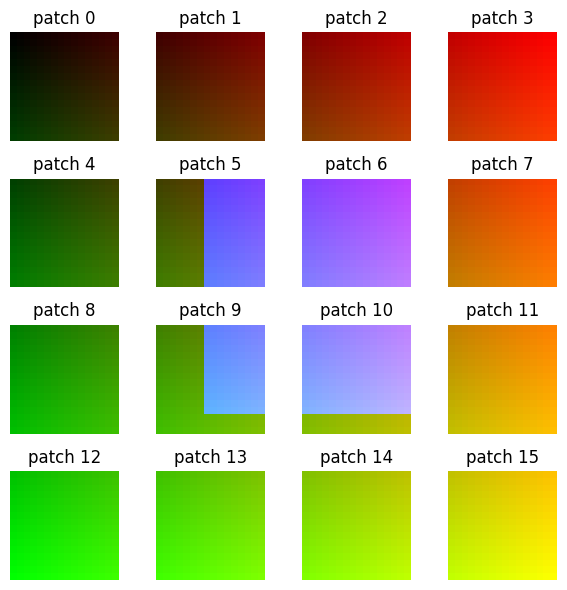

In [6]:
# Visualizamos algunos patches para reforzar la idea de secuencia visual.

patch_size = 16
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
patches_imagen = imagen.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
patches_imagen = patches_imagen.permute(1, 2, 0, 3, 4).contiguous()

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        patch = patches_imagen[i, j].permute(1, 2, 0).cpu().numpy()
        ax.imshow(patch)
        ax.set_title(f"patch {i*4+j}")
        ax.axis("off")

plt.tight_layout()
plt.show()

### **Objetivos de preentrenamiento multimodal**

#### **MLM, MRM, ITM, WRA, contraste, captioning e instruction tuning**

Los papers de la Semana 9 se diferencian no solo por arquitectura, sino también por sus objetivos de entrenamiento.

| Objetivo | Significado | Modelos asociados | Qué fuerza a aprender |
|---|---|---|---|
| MLM | Masked Language Modeling | BERT, VisualBERT, UNITER | Contexto textual condicionado por imagen |
| MRM | Masked Region Modeling | LXMERT, UNITER | Reconstrucción o predicción de regiones visuales |
| ITM | Image-Text Matching | UNITER, BLIP | Si una imagen y un texto corresponden |
| WRA | Word-Region Alignment | UNITER | Alineamiento fino palabra-región |
| Contrastive loss | Pérdida contrastiva imagen-texto | CLIP, CoCa, FLAVA | Cercanía de pares correctos y separación de pares incorrectos |
| Captioning loss | Generación autoregresiva de texto | SimVLM, CoCa, BLIP | Describir o responder con lenguaje natural |
| Instruction tuning | Ajuste con instrucciones | LLaVA, Qwen2.5-VL, InternVL | Seguir órdenes multimodales conversacionales |

#### **Comentario crítico del modelo**

Dos modelos con arquitectura parecida pueden comportarse de forma distinta si fueron entrenados con objetivos distintos. Por ejemplo, un modelo contrastivo puede ser excelente para retrieval pero limitado para explicar una imagen, un modelo generativo puede producir texto fluido, pero alucinar objetos si no está bien grounded.

In [7]:
# Pérdida contrastiva imagen-texto estilo CLIP.
# Esta implementación se usa luego para la línea base de recuperación.

def perdida_contrastiva_bidireccional(
    emb_imagen: torch.Tensor,
    emb_texto: torch.Tensor,
    temperatura: float = 0.07
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    emb_imagen: [N, D]
    emb_texto: [N, D]
    Se asume que imagen_i corresponde a texto_i.
    """
    emb_imagen = F.normalize(emb_imagen, dim=-1)
    emb_texto = F.normalize(emb_texto, dim=-1)
    logits = emb_imagen @ emb_texto.T / temperatura
    etiquetas = torch.arange(logits.shape[0], device=logits.device)
    perdida_i2t = F.cross_entropy(logits, etiquetas)
    perdida_t2i = F.cross_entropy(logits.T, etiquetas)
    perdida = (perdida_i2t + perdida_t2i) / 2
    return perdida, logits

N, D = 8, 32
base = torch.randn(N, D, device=device)
emb_imagen_demo = base + 0.05 * torch.randn(N, D, device=device)
emb_texto_demo = base + 0.05 * torch.randn(N, D, device=device)

perdida, logits = perdida_contrastiva_bidireccional(emb_imagen_demo, emb_texto_demo)
print("Pérdida contrastiva didáctica:", float(perdida.detach().cpu()))
print("Matriz de similitud:", tuple(logits.shape))

Pérdida contrastiva didáctica: 6.0784717788919806e-05
Matriz de similitud: (8, 8)


In [8]:
# Objetivo ITM didáctico: clasificar si un par imagen-texto corresponde o no.
# Esto no reemplaza un modelo real, pero permite discutir el objetivo.

class ClasificadorITM(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim * 4, dim),
            nn.ReLU(),
            nn.Linear(dim, 2)
        )

    def forward(self, img: torch.Tensor, txt: torch.Tensor) -> torch.Tensor:
        caracteristicas = torch.cat([img, txt, img * txt, torch.abs(img - txt)], dim=-1)
        return self.mlp(caracteristicas)

clasificador_itm = ClasificadorITM(D).to(device)

pares_img = F.normalize(emb_imagen_demo, dim=-1)
pares_txt_positivos = F.normalize(emb_texto_demo, dim=-1)
pares_txt_negativos = torch.roll(pares_txt_positivos, shifts=1, dims=0)

x_img = torch.cat([pares_img, pares_img], dim=0)
x_txt = torch.cat([pares_txt_positivos, pares_txt_negativos], dim=0)
y_itm = torch.cat([
    torch.ones(N, dtype=torch.long, device=device),
    torch.zeros(N, dtype=torch.long, device=device)
])

logits_itm = clasificador_itm(x_img, x_txt)
perdida_itm = F.cross_entropy(logits_itm, y_itm)

print("Pérdida ITM didáctica:", float(perdida_itm.detach().cpu()))
print("Forma de logits ITM:", tuple(logits_itm.shape))

Pérdida ITM didáctica: 0.6877709627151489
Forma de logits ITM: (16, 2)


### **Dual encoder: recuperación imagen-texto**
#### CLIP como puente con Semana 5

Un dual encoder procesa imagen y texto por separado:

```text
imagen -> encoder visual -> embedding visual
texto  -> encoder textual -> embedding textual
```

Luego compara embeddings con similitud coseno o producto punto. Esta familia es excelente para **recuperación cruzada** porque permite indexar imágenes y textos por separado. Pero no basta con mostrar embeddings, la evaluación debe incluir:

- matriz de similitud imagen-texto,
- **Recall@1** y **Recall@5**,
- ranking correcto/incorrecto,
- análisis de errores,
- discusión de costo y escalabilidad.

#### **Comentario crítico del modelo**

CLIP puede recuperar una imagen correcta aunque no tenga comprensión profunda de relaciones composicionales. Por eso retrieval no debe confundirse automáticamente con razonamiento multimodal.

In [9]:
# Línea base autocontenida de recuperación imagen-texto.
# Simulamos embeddings con pares correctos conocidos para medir Recall@K.

@dataclass
class EjemploMultimodal:
    id_imagen: str
    descripcion: str
    categoria_error: str = "sin_error"

ejemplos = [
    EjemploMultimodal("img_00", "un perro marrón corriendo en un parque"),
    EjemploMultimodal("img_01", "una factura con tabla de productos y total"),
    EjemploMultimodal("img_02", "un diagrama de arquitectura con módulos conectados"),
    EjemploMultimodal("img_03", "una persona usando una laptop en una oficina"),
    EjemploMultimodal("img_04", "un gráfico de barras con resultados experimentales"),
    EjemploMultimodal("img_05", "una calle urbana con autos y señales"),
    EjemploMultimodal("img_06", "una página de documento con texto y encabezados"),
    EjemploMultimodal("img_07", "una imagen médica con regiones resaltadas"),
]

def crear_embeddings_pareados(n: int, dim: int, ruido: float = 0.12) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Crea embeddings de imagen y texto con correspondencia diagonal.
    El ruido controla dificultad del retrieval.
    """
    base = torch.randn(n, dim, device=device)
    emb_img = base + ruido * torch.randn(n, dim, device=device)
    emb_txt = base + ruido * torch.randn(n, dim, device=device)
    return F.normalize(emb_img, dim=-1), F.normalize(emb_txt, dim=-1)

emb_img, emb_txt = crear_embeddings_pareados(len(ejemplos), 64, ruido=0.16)
similitud = emb_img @ emb_txt.T

print("Matriz de similitud imagen-texto:", tuple(similitud.shape))
pd.DataFrame(
    similitud.detach().cpu().numpy(),
    index=[e.id_imagen for e in ejemplos],
    columns=[f"txt_{i}" for i in range(len(ejemplos))]
).round(3)

Matriz de similitud imagen-texto: (8, 8)


,txt_0,txt_1,txt_2,txt_3,txt_4,txt_5,txt_6,txt_7
img_00,0.960,-0.070,-0.040,-0.030,-0.091,-0.060,-0.063,0.069
img_01,-0.121,0.973,-0.021,0.066,0.085,0.235,0.035,-0.053
img_02,-0.082,-0.077,0.965,0.080,-0.117,0.074,0.028,0.149
img_03,-0.045,0.074,0.092,0.983,0.133,-0.074,-0.171,-0.004
img_04,-0.158,0.095,-0.064,0.134,0.983,0.015,-0.132,0.002
img_05,-0.115,0.241,0.117,-0.076,0.000,0.974,0.021,0.007
img_06,-0.017,0.040,-0.012,-0.126,-0.120,-0.038,0.967,-0.015
img_07,0.060,-0.060,0.096,-0.029,0.005,0.096,0.060,0.977


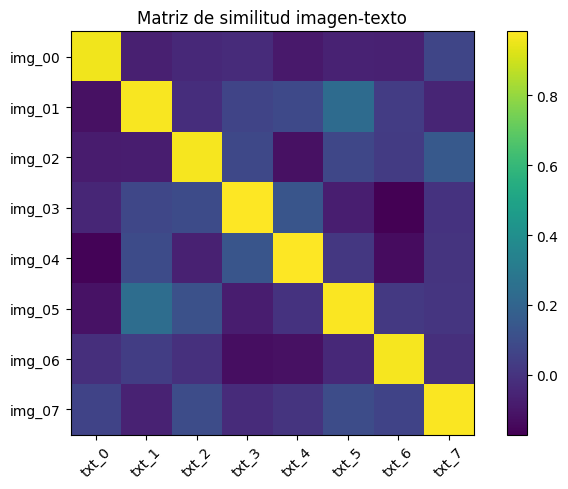

In [10]:
# Visualización de matriz de similitud.

plt.figure(figsize=(7, 5))
plt.imshow(similitud.detach().cpu().numpy())
plt.xticks(range(len(ejemplos)), [f"txt_{i}" for i in range(len(ejemplos))], rotation=45)
plt.yticks(range(len(ejemplos)), [e.id_imagen for e in ejemplos])
plt.title("Matriz de similitud imagen-texto")
plt.colorbar()
plt.tight_layout()
plt.show()

In [11]:
# Métricas Recall@K para recuperación imagen -> texto y texto -> imagen.

def recall_at_k(sim: torch.Tensor, k: int = 1, direccion: str = "i2t") -> float:
    """
    sim: matriz [N, N], donde la diagonal representa pares correctos.
    direccion:
      i2t: imagen a texto
      t2i: texto a imagen
    """
    if direccion == "t2i":
        sim = sim.T
    n = sim.shape[0]
    topk = torch.topk(sim, k=min(k, n), dim=1).indices
    objetivo = torch.arange(n, device=sim.device).view(-1, 1)
    aciertos = (topk == objetivo).any(dim=1).float()
    return float(aciertos.mean().detach().cpu())

metricas_retrieval = {
    "Recall@1 imagen->texto": recall_at_k(similitud, k=1, direccion="i2t"),
    "Recall@5 imagen->texto": recall_at_k(similitud, k=5, direccion="i2t"),
    "Recall@1 texto->imagen": recall_at_k(similitud, k=1, direccion="t2i"),
    "Recall@5 texto->imagen": recall_at_k(similitud, k=5, direccion="t2i"),
}

pd.DataFrame([metricas_retrieval]).round(3)

,Recall@1 imagen→texto,Recall@5 imagen→texto,Recall@1 texto→imagen,Recall@5 texto→imagen
0,1.0,1.0,1.0,1.0


In [12]:
# Ranking correcto/incorrecto para análisis cualitativo.

def ranking_i2t(sim: torch.Tensor, ejemplos: List[EjemploMultimodal], top_k: int = 3) -> pd.DataFrame:
    filas = []
    indices = torch.topk(sim, k=top_k, dim=1).indices.detach().cpu().numpy()
    valores = torch.topk(sim, k=top_k, dim=1).values.detach().cpu().numpy()

    for i, ejemplo in enumerate(ejemplos):
        for rank in range(top_k):
            j = int(indices[i, rank])
            filas.append({
                "consulta_imagen": ejemplo.id_imagen,
                "rank": rank + 1,
                "texto_recuperado": ejemplos[j].descripcion,
                "score": float(valores[i, rank]),
                "es_correcto": i == j
            })
    return pd.DataFrame(filas)

ranking = ranking_i2t(similitud, ejemplos, top_k=3)
ranking

,consulta_imagen,rank,texto_recuperado,score,es_correcto
0,img_00,1,un perro marrón corriendo en un parque,0.959757,True
1,img_00,2,una imagen médica con regiones resaltadas,0.069117,False
2,img_00,3,una persona usando una laptop en una oficina,-0.029877,False
3,img_01,1,una factura con tabla de productos y total,0.972877,True
4,img_01,2,una calle urbana con autos y señales,0.234707,False
5,img_01,3,un gráfico de barras con resultados experiment...,0.085065,False
6,img_02,1,un diagrama de arquitectura con módulos conect...,0.965275,True
7,img_02,2,una imagen médica con regiones resaltadas,0.149399,False
8,img_02,3,una persona usando una laptop en una oficina,0.079897,False
9,img_03,1,una persona usando una laptop en una oficina,0.982858,True


In [13]:
# Análisis de errores básico en retrieval.
# En un laboratorio real, estas categorías se llenan revisando imágenes y textos.

def clasificar_error_retrieval(fila: pd.Series) -> str:
    if fila["es_correcto"]:
        return "correcto"
    texto = fila["texto_recuperado"]
    if "documento" in texto or "factura" in texto:
        return "confusión_documental"
    if "gráfico" in texto or "diagrama" in texto:
        return "confusión_visual_estructural"
    if "persona" in texto or "perro" in texto:
        return "confusión_objeto_escena"
    return "otro"

errores = ranking[ranking["rank"] == 1].copy()
errores["categoria_error"] = errores.apply(clasificar_error_retrieval, axis=1)
errores[["consulta_imagen", "texto_recuperado", "es_correcto", "categoria_error"]]

,consulta_imagen,texto_recuperado,es_correcto,categoria_error
0,img_00,un perro marrón corriendo en un parque,True,correcto
3,img_01,una factura con tabla de productos y total,True,correcto
6,img_02,un diagrama de arquitectura con módulos conect...,True,correcto
9,img_03,una persona usando una laptop en una oficina,True,correcto
12,img_04,un gráfico de barras con resultados experiment...,True,correcto
15,img_05,una calle urbana con autos y señales,True,correcto
18,img_06,una página de documento con texto y encabezados,True,correcto
21,img_07,una imagen médica con regiones resaltadas,True,correcto


### **Fusion encoder: VisualBERT, UNITER y ViLT**

#### **Comparación arquitectónica explícita**

| Modelo | Entrada visual | Arquitectura | Ventaja | Limitación |
|---|---|---|---|---|
| VisualBERT | regiones | single-stream | simple y directo | depende de detector |
| UNITER | regiones | single-stream preentrenado | fuerte alineamiento | costoso |
| ViLT | patches | single-stream ligero | eficiente | menor capacidad visual especializada |

#### **Comentario sobre VisualBERT**

VisualBERT toma embeddings textuales y embeddings de regiones visuales, los concatena y los procesa en una pila Transformer. Es una extensión natural de BERT hacia visión-lenguaje.

#### **Comentario sobre UNITER**

UNITER representa una etapa más fuerte de preentrenamiento universal imagen-texto. La clave no es solo concatenar tokens, sino entrenar con objetivos que obligan a alinear imagen y lenguaje.

#### **Comentario sobre ViLT**

ViLT simplifica el pipeline al evitar detectores de objetos pesados. La imagen se procesa como patches, lo que reduce dependencia de módulos externos y acelera el flujo, aunque puede sacrificar especialización visual.

In [14]:
# Fusion encoder mínimo: concatenamos tokens textuales y tokens visuales.
# Esta celda emula la idea single-stream, no reproduce VisualBERT/UNITER/ViLT completos.

class FusionEncoderDidactico(nn.Module):
    def __init__(self, dim: int = 64, num_heads: int = 4, num_layers: int = 2):
        super().__init__()
        capa = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=num_heads,
            dim_feedforward=dim * 4,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(capa, num_layers=num_layers)
        self.norm = nn.LayerNorm(dim)

    def forward(self, tokens_texto: torch.Tensor, tokens_visuales: torch.Tensor) -> torch.Tensor:
        secuencia = torch.cat([tokens_texto, tokens_visuales], dim=1)
        salida = self.encoder(secuencia)
        return self.norm(salida)

dim = 64
batch = 2
num_tokens_texto = 6
num_tokens_visuales = 16

tokens_texto = torch.randn(batch, num_tokens_texto, dim, device=device)
tokens_visuales = torch.randn(batch, num_tokens_visuales, dim, device=device)

fusion_encoder = FusionEncoderDidactico(dim=dim).to(device)
salida_fusion = fusion_encoder(tokens_texto, tokens_visuales)

print("Tokens de texto:", tuple(tokens_texto.shape))
print("Tokens visuales:", tuple(tokens_visuales.shape))
print("Salida fusionada:", tuple(salida_fusion.shape))

Tokens de texto: (2, 6, 64)
Tokens visuales: (2, 16, 64)
Salida fusionada: (2, 22, 64)


In [15]:
# Análisis de costo aproximado de self-attention.
# La atención completa crece cuadráticamente con la longitud de secuencia.

def costo_atencion(longitud: int, dim: int) -> int:
    return longitud * longitud * dim

longitudes = []
for n_texto in [16, 32, 64]:
    for n_visual in [49, 196, 576]:
        L = n_texto + n_visual
        longitudes.append({
            "tokens_texto": n_texto,
            "tokens_visuales": n_visual,
            "longitud_total": L,
            "costo_relativo_L2D": costo_atencion(L, dim=768)
        })

df_costo = pd.DataFrame(longitudes)
df_costo

,tokens_texto,tokens_visuales,longitud_total,costo_relativo_L2D
0,16,49,65,3244800
1,16,196,212,34516992
2,16,576,592,269156352
3,32,49,81,5038848
4,32,196,228,39923712
5,32,576,608,283901952
6,64,49,113,9806592
7,64,196,260,51916800
8,64,576,640,314572800


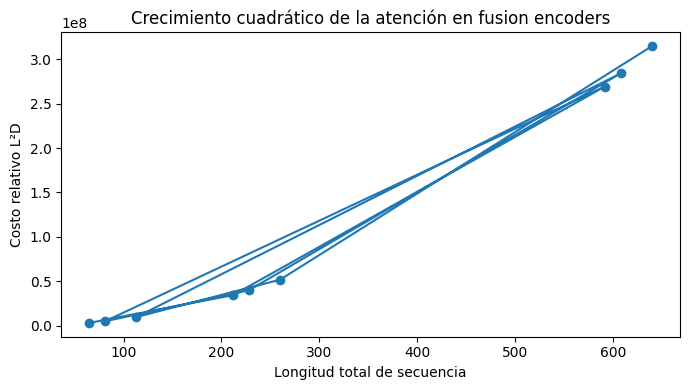

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(df_costo["longitud_total"], df_costo["costo_relativo_L2D"], marker="o")
plt.xlabel("Longitud total de secuencia")
plt.ylabel("Costo relativo L²D")
plt.title("Crecimiento cuadrático de la atención en fusion encoders")
plt.tight_layout()
plt.show()

### **Cross-attention: ViLBERT, LXMERT, Flamingo y BLIP-2**

#### **La idea central**

Cross-attention permite que una modalidad consulte a otra:

```text
queries: tokens de texto
keys/values: tokens visuales
```

o al revés:

```text
queries: tokens visuales
keys/values: tokens de texto
```

Esto cambia la interpretación de la atención. En self-attention, todos los tokens pertenecen a una secuencia común. En cross-attention, una modalidad pregunta y la otra responde.

#### **Comentario sobre ViLBERT**

ViLBERT mantiene dos flujos separados, uno visual y otro textual. La interacción aparece en capas de co-attention. Esto permite preservar procesamiento especializado antes de fusionar.

#### **Comentario sobre LXMERT**

LXMERT combina encoder de objetos, encoder de lenguaje y encoder cross-modality. Es muy útil para explicar VQA y razonamiento visual porque fuerza una interacción explícita entre lenguaje y objetos.

#### **Comentario sobre Flamingo**

Flamingo introduce un patrón influyente para few-shot multimodal con texto, imágenes y video intercalados. Su importancia para esta semana es conceptual: muestra cómo conectar grandes modelos de lenguaje con entradas visuales mediante capas especializadas de atención.

#### **Comentario sobre BLIP-2**

BLIP-2 propone un **Q-Former** que conecta un image encoder congelado con un LLM congelado. Esta solución reduce el costo de entrenamiento frente a entrenar todo end-to-end y explica una familia moderna de modelos multimodales modulares.

In [17]:
# Cross-attention didáctica.
# Los tokens de consulta pueden ser texto, los tokens de memoria pueden ser imagen.

class CrossAttentionDidactica(nn.Module):
    def __init__(self, dim: int, num_heads: int = 4):
        super().__init__()
        self.atencion = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, consultas: torch.Tensor, memoria: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        salida, pesos = self.atencion(
            query=consultas,
            key=memoria,
            value=memoria,
            need_weights=True,
            average_attn_weights=False
        )
        return self.norm(consultas + salida), pesos

cross_attention = CrossAttentionDidactica(dim=64, num_heads=4).to(device)

tokens_pregunta = torch.randn(1, 5, 64, device=device)     # ejemplo: palabras de una pregunta
tokens_imagen = torch.randn(1, 16, 64, device=device)      # ejemplo: regiones o patches

salida_cross, pesos_cross = cross_attention(tokens_pregunta, tokens_imagen)

print("Consultas:", tuple(tokens_pregunta.shape))
print("Memoria visual:", tuple(tokens_imagen.shape))
print("Salida cross-modal:", tuple(salida_cross.shape))
print("Pesos de atención:", tuple(pesos_cross.shape))

Consultas: (1, 5, 64)
Memoria visual: (1, 16, 64)
Salida cross-modal: (1, 5, 64)
Pesos de atención: (1, 4, 5, 16)


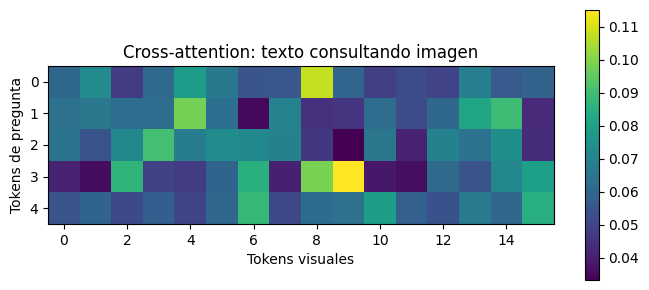

In [18]:
# Visualización de cross-attention promedio sobre cabezas.

pesos_promedio = pesos_cross.mean(dim=1)[0].detach().cpu().numpy()

plt.figure(figsize=(7, 3))
plt.imshow(pesos_promedio)
plt.xlabel("Tokens visuales")
plt.ylabel("Tokens de pregunta")
plt.title("Cross-attention: texto consultando imagen")
plt.colorbar()
plt.tight_layout()
plt.show()

In [19]:
# Q-Former didáctico: un conjunto pequeño de queries aprendibles consulta tokens visuales.
# Esto ilustra la lógica de BLIP-2 sin descargar el modelo real.

class QFormerDidactico(nn.Module):
    def __init__(self, dim_visual: int = 64, dim_q: int = 64, num_queries: int = 8, num_heads: int = 4):
        super().__init__()
        self.queries = nn.Parameter(torch.randn(1, num_queries, dim_q) * 0.02)
        self.proyector_visual = nn.Linear(dim_visual, dim_q)
        self.cross_attn = CrossAttentionDidactica(dim=dim_q, num_heads=num_heads)
        self.ffn = nn.Sequential(
            nn.LayerNorm(dim_q),
            nn.Linear(dim_q, dim_q * 4),
            nn.GELU(),
            nn.Linear(dim_q * 4, dim_q)
        )

    def forward(self, tokens_visuales: torch.Tensor) -> torch.Tensor:
        b = tokens_visuales.shape[0]
        memoria = self.proyector_visual(tokens_visuales)
        queries = self.queries.expand(b, -1, -1)
        salida, _ = self.cross_attn(queries, memoria)
        return salida + self.ffn(salida)

qformer = QFormerDidactico().to(device)
tokens_q = qformer(tokens_imagen)

print("Tokens visuales originales:", tuple(tokens_imagen.shape))
print("Queries visuales aprendidas:", tuple(tokens_q.shape))
print("Interpretación: el Q-Former comprime una imagen en un número pequeño de tokens útiles para el LLM.")

Tokens visuales originales: (1, 16, 64)
Queries visuales aprendidas: (1, 8, 64)
Interpretación: el Q-Former comprime una imagen en un número pequeño de tokens útiles para el LLM.


### **Encoder-decoder multimodal: captioning y generación**

#### **BLIP y la transición hacia generación**

Los modelos encoder-decoder multimodales conectan comprensión visual con generación textual. A diferencia de CLIP, no solo recuperan o clasifican, producen lenguaje natural.

Un caption puede sonar correcto y aun así ser incompleto o no estar grounded. Por ejemplo, si el modelo menciona "un médico" porque ve una bata blanca, pero la imagen no permite verificar la profesión, hay una inferencia posiblemente alucinada.

In [20]:
# Evaluación didáctica de captions.
# No usamos un modelo pesado aquí, evaluamos captions hipotéticos para mostrar el protocolo.

caption_humano = "una persona revisa una factura impresa sobre una mesa junto a una laptop"
caption_modelo_a = "una persona trabaja con documentos y una laptop"
caption_modelo_b = "un contador revisa una factura médica con un sello rojo"

objetos_visibles = {"persona", "factura", "mesa", "laptop", "documentos"}
terminos_potencialmente_alucinados = {"contador", "médica", "sello", "rojo"}

def tokenizar_simple(texto: str) -> List[str]:
    texto = texto.lower()
    for signo in [".", ",", ";", ":", "¿", "?", "¡", "!", "(", ")"]:
        texto = texto.replace(signo, "")
    return texto.split()

def comparar_caption(caption_ref: str, caption_gen: str, visibles: set, sospechosos: set) -> Dict[str, object]:
    ref = set(tokenizar_simple(caption_ref))
    gen = set(tokenizar_simple(caption_gen))
    inter = ref & gen
    cobertura = len(inter) / max(1, len(ref))
    omisiones = sorted(list(ref - gen))
    alucinaciones = sorted([t for t in gen if t in sospechosos and t not in visibles])
    return {
        "caption_generado": caption_gen,
        "cobertura_lexica_aproximada": round(cobertura, 3),
        "omisiones_aproximadas": omisiones,
        "alucinaciones_sospechosas": alucinaciones,
        "requiere_revision_humana": len(alucinaciones) > 0 or cobertura < 0.35
    }

pd.DataFrame([
    comparar_caption(caption_humano, caption_modelo_a, objetos_visibles, terminos_potencialmente_alucinados),
    comparar_caption(caption_humano, caption_modelo_b, objetos_visibles, terminos_potencialmente_alucinados),
])

,caption_generado,cobertura_lexica_aproximada,omisiones_aproximadas,alucinaciones_sospechosas,requiere_revision_humana
0,una persona trabaja con documentos y una laptop,0.3,"[a, factura, impresa, junto, mesa, revisa, sobre]",[],True
1,un contador revisa una factura médica con un s...,0.3,"[a, impresa, junto, laptop, mesa, persona, sobre]","[contador, médica, rojo, sello]",True


### **Visual instruction tuning: LLaVA y LLaVA-1.5**

#### **De captioning a asistente multimodal**

LLaVA conecta un vision encoder con un LLM mediante un proyector y entrena el sistema con datos de instrucciones multimodales. Esto cambia la tarea:

```text
Captioning:
imagen -> descripción

Visual instruction tuning:
imagen + instrucción -> respuesta conversacional
```

#### **Comentario sobre LLaVA**

La idea central no es solo agregar una imagen al LLM. El punto clave es construir pares de instrucción-respuesta donde el modelo aprenda a obedecer preguntas visuales, razonar sobre contenido observado y responder en formato conversacional.

#### **Comentario sobre LLaVA-1.5**

LLaVA-1.5 muestra que un conector simple, datos académicos bien seleccionados y un formato de respuestas más controlado pueden producir una línea base fuerte. Para el curso, este paper es importante porque enseña una lección de ingeniería: **datos, formato y evaluación pueden ser tan importantes como el tamaño del modelo**.

In [21]:
# Esquema mínimo de un ejemplo de visual instruction tuning.
# Se muestra como estructura de datos, no como entrenamiento pesado.

ejemplo_llava = {
    "id": "mcc225_img_001",
    "imagen": "ruta/a/imagen_factura.png",
    "conversacion": [
        {
            "rol": "usuario",
            "contenido": "<imagen> ¿Qué elementos principales aparecen en la imagen?"
        },
        {
            "rol": "asistente",
            "contenido": "Aparece una factura con una tabla de productos, un total y texto administrativo."
        },
        {
            "rol": "usuario",
            "contenido": "¿Hay evidencia visual suficiente para afirmar que está pagada?"
        },
        {
            "rol": "asistente",
            "contenido": "No necesariamente. Se necesitaría observar un sello, recibo o campo de estado de pago."
        }
    ],
    "comentario_docente": "La segunda respuesta evita inferir un estado no observado, esto reduce alucinación."
}

ejemplo_llava

{'id': 'mcc225_img_001',
 'imagen': 'ruta/a/imagen_factura.png',
 'conversacion': [{'rol': 'usuario',
   'contenido': '<imagen> ¿Qué elementos principales aparecen en la imagen?'},
  {'rol': 'asistente',
   'contenido': 'Aparece una factura con una tabla de productos, un total y texto administrativo.'},
  {'rol': 'usuario',
   'contenido': '¿Hay evidencia visual suficiente para afirmar que está pagada?'},
  {'rol': 'asistente',
   'contenido': 'No necesariamente. Se necesitaría observar un sello, recibo o campo de estado de pago.'}],
 'comentario_docente': 'La segunda respuesta evita inferir un estado no observado; esto reduce alucinación.'}

In [22]:
# Proyector visual hacia espacio del LLM.
# Esta pieza representa el puente usado en muchos MLLMs: embeddings visuales -> dimensión del lenguaje.

class ProyectorVisualLLM(nn.Module):
    def __init__(self, dim_visual: int = 64, dim_llm: int = 128):
        super().__init__()
        self.proyector = nn.Sequential(
            nn.Linear(dim_visual, dim_llm),
            nn.GELU(),
            nn.Linear(dim_llm, dim_llm)
        )

    def forward(self, tokens_visuales: torch.Tensor) -> torch.Tensor:
        return self.proyector(tokens_visuales)

proyector_llm = ProyectorVisualLLM(dim_visual=64, dim_llm=128).to(device)
tokens_para_llm = proyector_llm(tokens_q)

print("Tokens del Q-Former:", tuple(tokens_q.shape))
print("Tokens proyectados al espacio del LLM:", tuple(tokens_para_llm.shape))
print("Interpretación: estos tokens pueden funcionar como prefijo visual o contexto visual para un LLM.")

Tokens del Q-Former: (1, 8, 64)
Tokens proyectados al espacio del LLM: (1, 8, 128)
Interpretación: estos tokens pueden funcionar como prefijo visual o contexto visual para un LLM.


### **Modelos modernos: Qwen2.5-VL, InternVL y Molmo**

#### **Qwen2.5-VL**

Qwen2.5-VL es útil para discutir capacidades modernas que exceden el captioning clásico: documentos, tablas, diagramas, localización mediante puntos o bounding boxes, video largo y uso de herramientas en escenarios agentic visuales.

> Comentario crítico: su valor industrial está en tareas documentales y visuales complejas, pero su evaluación debe separar comprensión visual real, OCR, razonamiento, grounding y obediencia a instrucciones.

#### **InternVL2.5**

InternVL2.5 permite discutir escalamiento de modelo, escalamiento de datos y **test-time scaling**. Es relevante para razonamiento multimodal, documentos, video, grounding, multilingualidad y detección de alucinación.

> Comentario crítico: InternVL no debe presentarse solo como "otro modelo grande", sino como caso de estudio sobre cómo escalar modelos abiertos y cómo medir rendimiento de forma más rigurosa.

#### **Molmo/PixMo**

Molmo/PixMo es importante por la discusión sobre apertura: pesos abiertos, datos abiertos y construcción de VLMs fuertes sin depender completamente de destilación de modelos propietarios.

> Comentario crítico: para investigación, la trazabilidad de datos y recetas de entrenamiento puede ser tan importante como el puntaje final en benchmarks.

In [23]:
# Ficha comparativa editable de modelos modernos.
# Los estudiantes pueden completar o corregir esta tabla después de leer los papers.

modelos_modernos = pd.DataFrame([
    {
        "Modelo": "Qwen2.5-VL",
        "Fortaleza": "documentos, tablas, diagramas, grounding y video largo",
        "Mecanismo relevante": "ViT dinámico, resolución variable, LLM Qwen",
        "Riesgo experimental": "costo alto y evaluación superficial de grounding"
    },
    {
        "Modelo": "InternVL2.5",
        "Fortaleza": "razonamiento, documentos, multi-imagen/video, grounding y test-time scaling",
        "Mecanismo relevante": "escalamiento de visión, lenguaje, datos y evaluación",
        "Riesgo experimental": "confundir benchmark alto con confiabilidad total"
    },
    {
        "Modelo": "Molmo/PixMo",
        "Fortaleza": "apertura de pesos, datos y recetas de entrenamiento",
        "Mecanismo relevante": "datasets visuales detallados y pointing 2D",
        "Riesgo experimental": "comparabilidad y cobertura de tareas especializadas"
    }
])

modelos_modernos

,Modelo,Fortaleza,Mecanismo relevante,Riesgo experimental
0,Qwen2.5-VL,"documentos, tablas, diagramas, grounding y vid...","ViT dinámico, resolución variable, LLM Qwen",costo alto y evaluación superficial de grounding
1,InternVL2.5,"razonamiento, documentos, multi-imagen/video, ...","escalamiento de visión, lenguaje, datos y eval...",confundir benchmark alto con confiabilidad total
2,Molmo/PixMo,"apertura de pesos, datos y recetas de entrenam...",datasets visuales detallados y pointing 2D,comparabilidad y cobertura de tareas especiali...


### **Matriz final de comparación**

Esta matriz resume decisiones de ingeniería. El estudiante debe poder defender cada fila con argumentos técnicos, no solo repetir nombres de modelos.

| Modelo | Tipo | Comprensión | Generación | Grounding | Costo | Uso recomendado |
|---|---|---:|---:|---:|---:|---|
| CLIP | dual encoder | alta | no | bajo | bajo | retrieval |
| ViLT | fusion encoder | media/alta | no | limitado | bajo | clasificación/VQA simple |
| BLIP | encoder-decoder | alta | sí | medio | medio | captioning/VQA |
| BLIP-2 | Q-Former + LLM | alta | sí | medio | medio | VQA/generación |
| LLaVA | instruction-tuned MLLM | alta | sí | variable | medio/alto | asistente visual |
| Qwen2.5-VL | MLLM moderno | alta | sí | alto | alto | documentos, tablas, diagramas, agentes |

#### **Comentario crítico**

La matriz no debe leerse como ranking universal. Un sistema de búsqueda puede preferir CLIP por costo y velocidad. Un sistema de análisis documental puede preferir Qwen2.5-VL. Un laboratorio con recursos limitados puede usar BLIP-2 o LLaVA pequeño para demostración, pero mantener CLIP como baseline experimental.

In [24]:
matriz_final = pd.DataFrame([
    {
        "Modelo": "CLIP",
        "Tipo": "dual encoder",
        "Comprensión": "alta",
        "Generación": "no",
        "Grounding": "bajo",
        "Costo": "bajo",
        "Uso recomendado": "retrieval"
    },
    {
        "Modelo": "ViLT",
        "Tipo": "fusion encoder",
        "Comprensión": "media/alta",
        "Generación": "no",
        "Grounding": "limitado",
        "Costo": "bajo",
        "Uso recomendado": "clasificación/VQA simple"
    },
    {
        "Modelo": "BLIP",
        "Tipo": "encoder-decoder",
        "Comprensión": "alta",
        "Generación": "sí",
        "Grounding": "medio",
        "Costo": "medio",
        "Uso recomendado": "captioning/VQA"
    },
    {
        "Modelo": "BLIP-2",
        "Tipo": "Q-Former + LLM",
        "Comprensión": "alta",
        "Generación": "sí",
        "Grounding": "medio",
        "Costo": "medio",
        "Uso recomendado": "VQA/generación"
    },
    {
        "Modelo": "LLaVA",
        "Tipo": "instruction-tuned MLLM",
        "Comprensión": "alta",
        "Generación": "sí",
        "Grounding": "variable",
        "Costo": "medio/alto",
        "Uso recomendado": "asistente visual"
    },
    {
        "Modelo": "Qwen2.5-VL",
        "Tipo": "MLLM moderno",
        "Comprensión": "alta",
        "Generación": "sí",
        "Grounding": "alto",
        "Costo": "alto",
        "Uso recomendado": "documentos, tablas, diagramas, agentes"
    },
])

matriz_final

,Modelo,Tipo,Comprensión,Generación,Grounding,Costo,Uso recomendado
0,CLIP,dual encoder,alta,no,bajo,bajo,retrieval
1,ViLT,fusion encoder,media/alta,no,limitado,bajo,clasificación/VQA simple
2,BLIP,encoder-decoder,alta,sí,medio,medio,captioning/VQA
3,BLIP-2,Q-Former + LLM,alta,sí,medio,medio,VQA/generación
4,LLaVA,instruction-tuned MLLM,alta,sí,variable,medio/alto,asistente visual
5,Qwen2.5-VL,MLLM moderno,alta,sí,alto,alto,"documentos, tablas, diagramas, agentes"


### **Actividades** 

#### **Preguntas**

1. ¿Por qué BERT es una base conceptual válida, aunque no sea un modelo multimodal?
2. ¿Qué se gana y qué se pierde al pasar de regiones visuales a patches?
3. ¿Por qué CLIP puede ser excelente para retrieval y aun así débil para razonamiento relacional?
4. ¿Qué diferencia a VisualBERT de ViLBERT desde el punto de vista de fusión?
5. ¿Por qué UNITER es más que una concatenación de tokens texto-imagen?
6. ¿Qué ventaja computacional introduce ViLT?
7. ¿Por qué BLIP-2 usa componentes congelados y qué problema resuelve el Q-Former?
8. ¿Qué cambia cuando se pasa de captioning a visual instruction tuning?
9. ¿Por qué Qwen2.5-VL o InternVL no deben evaluarse solo con ejemplos bonitos?
10. ¿Qué modelo elegirías para un sistema de análisis de facturas, y cuál sería tu baseline?.

#### **Entregable sugerido**

Cada estudiante debe entregar una ficha de una página con:

- modelo elegido,
- paper asociado,
- familia arquitectónica,
- objetivo de preentrenamiento,
- modalidad de entrada,
- tarea recomendada,
- métrica mínima,
- limitación principal,
- riesgo de alucinación o falta de grounding,
- comparación contra un baseline.

### **Celdas opcionales para modelos reales**

#### **Uso responsable de modelos grandes**

Las siguientes extensiones son opcionales. Deben activarse solo si el entorno tiene internet, memoria suficiente y dependencias instaladas.

Posibles modelos livianos para demostración:

- `openai/clip-vit-base-patch32` para retrieval.
- `dandelin/vilt-b32-finetuned-vqa` para VQA simple.
- `Salesforce/blip-image-captioning-base` para captioning.
- Modelos LLaVA o Qwen-VL pequeños solo si la GPU y la memoria lo permiten.

> Según el curso, la ejecución real debe ir acompañada de análisis de errores. Ejecutar un modelo sin métricas ni discusión no constituye evidencia experimental.

In [25]:
# Celda opcional: detección de bibliotecas disponibles.
# No descarga modelos. Solo informa si el entorno tiene paquetes útiles.

paquetes = ["transformers", "PIL", "torchvision", "sklearn", "faiss", "open_clip"]
for paquete in paquetes:
    try:
        __import__(paquete)
        print(f"Disponible: {paquete}")
    except Exception as exc:
        print(f"No disponible o no importable: {paquete} -> {type(exc).__name__}")

Disponible: transformers
Disponible: PIL
Disponible: torchvision
Disponible: sklearn
Disponible: faiss
Disponible: open_clip


In [26]:
# Plantilla opcional para CLIP real con Hugging Face.
# Mantener ejecutar_modelo_real = False por defecto para evitar descargas involuntarias.

ejecutar_modelo_real = False

if ejecutar_modelo_real:
    from PIL import Image
    from transformers import CLIPProcessor, CLIPModel

    nombre_modelo = "openai/clip-vit-base-patch32"
    modelo = CLIPModel.from_pretrained(nombre_modelo).to(device)
    procesador = CLIPProcessor.from_pretrained(nombre_modelo)

    print("Modelo CLIP cargado:", nombre_modelo)
    print("Nota: agrega imágenes reales y textos candidatos para evaluar Recall@K.")
else:
    print("Modo seguro: no se descarga ningún modelo real. Cambia ejecutar_modelo_real=True si el entorno lo permite.")

Modo seguro: no se descarga ningún modelo real. Cambia ejecutar_modelo_real=True si el entorno lo permite.


### Referencias mínimas para lectura

#### Papers base y visión-lenguaje

- Devlin et al. - BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.
- Li et al. - VisualBERT: A Simple and Performant Baseline for Vision and Language.
- Lu et al. - ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks.
- Tan y Bansal - LXMERT: Learning Cross-Modality Encoder Representations from Transformers.
- Chen et al. - UNITER: Universal Image-Text Representation Learning.
- Kim et al. - ViLT: Vision-and-Language Transformer Without Convolution or Region Supervision.
- Singh et al. - FLAVA: A Foundational Language And Vision Alignment Model.
- Wang et al. - SimVLM: Simple Visual Language Model Pretraining with Weak Supervision.
- Yu et al. - CoCa: Contrastive Captioners are Image-Text Foundation Models.
- Li et al. - BLIP: Bootstrapping Language-Image Pre-training.
- Li et al. - BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models.
- Liu et al. - Visual Instruction Tuning / LLaVA.
- Liu et al. - Improved Baselines with Visual Instruction Tuning / LLaVA-1.5.
- Bai et al. - Qwen2.5-VL Technical Report.
- Chen et al. - InternVL2.5.
- Deitke et al. - Molmo and PixMo.

#### Lectura panorámica sugerida

- Du et al. - A Survey of Vision-Language Pre-Trained Models.